In [18]:
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean

In [19]:
ENGINEER_MOCK_DATA_LOCATION = 'engineer_mock_data.json' # TODO: user input
TASKS_MOCK_DATA_LOCATION = 'tasks_mock_data.json' # TODO: user input

# read file mock data
def read_file(file_path, validation_func):
    with open(file_path, 'r') as file:
        read_data = json.load(file)
        if (validation_func(read_data)):
            return read_data
        else:
            return []

# validate tasks list and object keys
def validate_tasks(tasks_mock): 
    if not isinstance(tasks_mock, list):
        return False
    for item in tasks_mock:
        if not isinstance(item, dict):
            return False
        if list(item.keys()) != ['task_id', 'skill_required', 'due_date', 'priority', 'dependency_level', 'module_knowledge', 'task_type']:
            return False
    return True

# validate engineer list and object keys
def validate_engineer(engineer_mock):
    if not isinstance(engineer_mock, list):
        return False
    for item in engineer_mock:
        if not isinstance(item, dict):
            return False
        if list(item.keys()) != ['engineer_id', 'skills', 'collab_ability', 'availability_index', 'impact', 'module_exposure', 'efficiency']:
            return False
    return True

engineer_mock = read_file(ENGINEER_MOCK_DATA_LOCATION, validate_engineer)
tasks_mock = read_file(TASKS_MOCK_DATA_LOCATION, validate_tasks)

print(engineer_mock)
print(tasks_mock)

[{'engineer_id': 1, 'skills': 'Spring Boot', 'collab_ability': 'High', 'availability_index': 21, 'impact': 13, 'module_exposure': 5, 'efficiency': 1.23}, {'engineer_id': 2, 'skills': 'React', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 21, 'module_exposure': 13, 'efficiency': 1.79}, {'engineer_id': 3, 'skills': 'React', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 13, 'module_exposure': 8, 'efficiency': 1.15}, {'engineer_id': 4, 'skills': 'React', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 21, 'module_exposure': 21, 'efficiency': 1.57}, {'engineer_id': 5, 'skills': 'Angular', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 34, 'module_exposure': 13, 'efficiency': 0.86}, {'engineer_id': 6, 'skills': 'Angular', 'collab_ability': 'High', 'availability_index': 21, 'impact': 13, 'module_exposure': 8, 'efficiency': 1.31}, {'engineer_id': 7, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impac

In [20]:
ENGINEER_SKILL_KEY_NAME = 'skills'
TASK_SKILL_KEY_NAME = 'skill_required'

# sort engineers or tasks by skills 
def sort_items_by_skills(items_list, item_key_name):
    sorted_items_dict = {}
    for item in items_list:
        if not item[item_key_name] in sorted_items_dict:
            sorted_items_dict[item[item_key_name]] = []
        sorted_items_dict[item[item_key_name]].append(item)
    return sorted_items_dict

sorted_engineer_dict = sort_items_by_skills(engineer_mock, ENGINEER_SKILL_KEY_NAME)
sorted_tasks_dict = sort_items_by_skills(tasks_mock, TASK_SKILL_KEY_NAME)

print(sorted_engineer_dict)
print(sorted_tasks_dict)

{'Spring Boot': [{'engineer_id': 1, 'skills': 'Spring Boot', 'collab_ability': 'High', 'availability_index': 21, 'impact': 13, 'module_exposure': 5, 'efficiency': 1.23}, {'engineer_id': 7, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 21, 'module_exposure': 34, 'efficiency': 1.54}, {'engineer_id': 8, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 55, 'module_exposure': 21, 'efficiency': 1.11}, {'engineer_id': 13, 'skills': 'Spring Boot', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 34, 'module_exposure': 5, 'efficiency': 1.12}, {'engineer_id': 15, 'skills': 'Spring Boot', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 13, 'module_exposure': 8, 'efficiency': 1.49}, {'engineer_id': 23, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 13, 'module_exposure': 13, 'efficiency': 1.17}, {'engineer_id': 25, 'skills': 'Spring Boot', 'collab_abil

In [21]:
LEVELS_TO_NUMERICS = {
    'Critical': 4,
    'High': 3,
    'Medium': 2,
    'Low': 1
}
SPRINT_LENGTH = 14 # taking a dummy sprint range of 14 days # TODO: user input
QUARTER_START_DATE = 1711929600 # April 1st 2024 # TODO: user input
QUARTER_END_DATE = 1720396740 # July 7th 2024 (to prevent short sprints) # TODO: user input

def task_complexity_calculation(task):
    return (LEVELS_TO_NUMERICS[task['priority']] + LEVELS_TO_NUMERICS[task['dependency_level']])*task['module_knowledge']

def engineer_complexity_handling_calculation(engineer):
    return LEVELS_TO_NUMERICS[engineer['collab_ability']] * engineer['impact'] * engineer['module_exposure']

def task_time_calculation(task):
    return int(task['due_date']) - QUARTER_START_DATE

def engineer_time_efficiency_calculation(engineer):
    return engineer['availability_index'] * engineer['efficiency'] * 3600

# find time and complexity co-efficients for tasks and engineers
def item_time_complexity_list_generator(item_dict, time_function, complexity_function):
    for skill in list(item_dict.keys()):
        for item in item_dict[skill]:
            item['time_coef'] = time_function(item)
            item['complexity_coef'] = complexity_function(item)
    return item_dict

quantified_engineer_dict = item_time_complexity_list_generator(sorted_engineer_dict, engineer_time_efficiency_calculation, engineer_complexity_handling_calculation)
quantified_task_dict = item_time_complexity_list_generator(sorted_tasks_dict, task_time_calculation, task_complexity_calculation)

print(quantified_engineer_dict)
print(quantified_task_dict)

{'Spring Boot': [{'engineer_id': 1, 'skills': 'Spring Boot', 'collab_ability': 'High', 'availability_index': 21, 'impact': 13, 'module_exposure': 5, 'efficiency': 1.23, 'time_coef': 92988.0, 'complexity_coef': 195}, {'engineer_id': 7, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 21, 'module_exposure': 34, 'efficiency': 1.54, 'time_coef': 72072.0, 'complexity_coef': 1428}, {'engineer_id': 8, 'skills': 'Spring Boot', 'collab_ability': 'Medium', 'availability_index': 13, 'impact': 55, 'module_exposure': 21, 'efficiency': 1.11, 'time_coef': 51948.00000000001, 'complexity_coef': 2310}, {'engineer_id': 13, 'skills': 'Spring Boot', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 34, 'module_exposure': 5, 'efficiency': 1.12, 'time_coef': 32256.000000000004, 'complexity_coef': 170}, {'engineer_id': 15, 'skills': 'Spring Boot', 'collab_ability': 'Low', 'availability_index': 8, 'impact': 13, 'module_exposure': 8, 'efficiency': 1.49, 'time_co

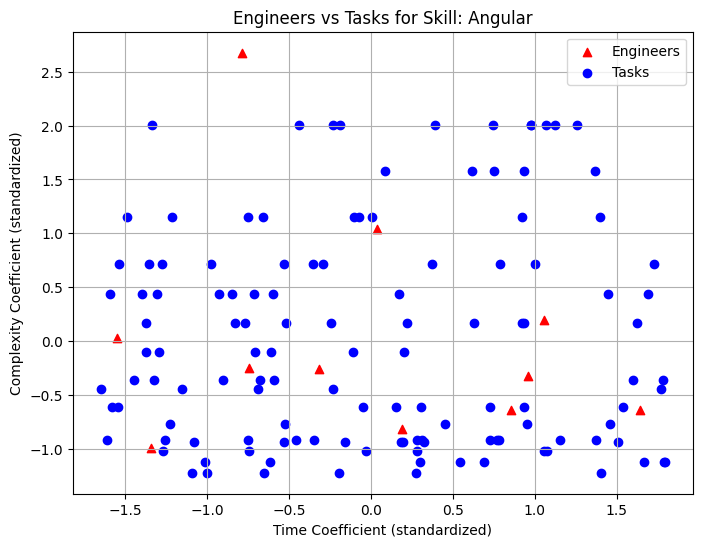

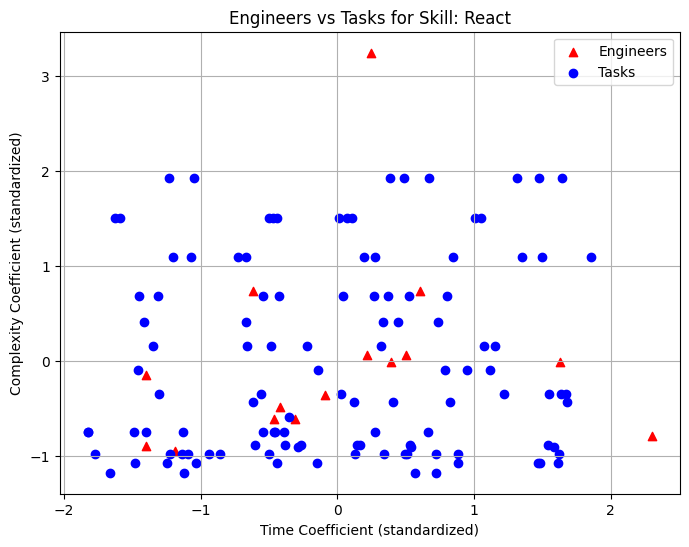

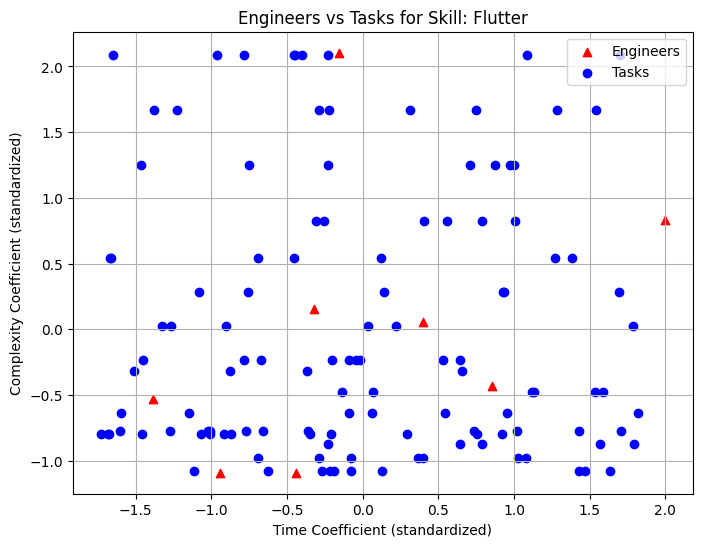

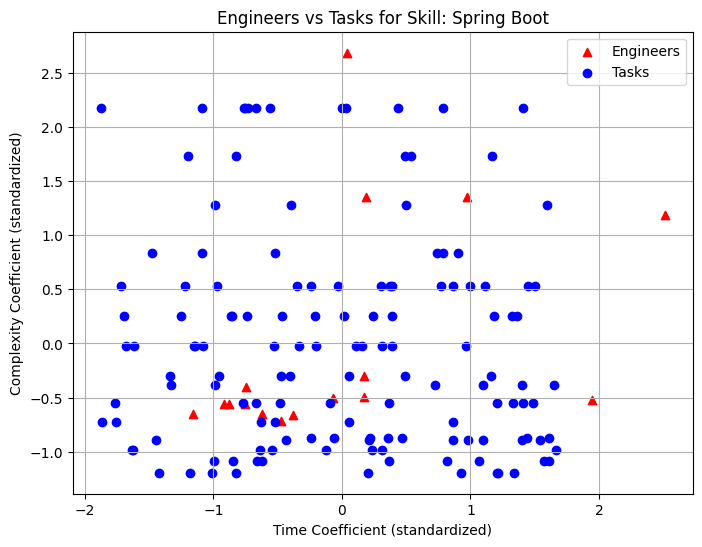

In [22]:
# Your original plotting functions
def plot_engineers_and_tasks_by_skill(engineer_dict, task_dict, skill):
    eng_items = engineer_dict.get(skill, [])
    task_items = task_dict.get(skill, [])

    # Extract coordinates
    eng_x = [e['time_coef'] for e in eng_items]
    eng_y = [e['complexity_coef'] for e in eng_items]

    task_x = [t['time_coef'] for t in task_items]
    task_y = [t['complexity_coef'] for t in task_items]

    plt.figure(figsize=(8, 6))

    # Engineers: Red triangles
    plt.scatter(eng_x, eng_y, color='red', label='Engineers', marker='^')

    # Tasks: Blue circles
    plt.scatter(task_x, task_y, color='blue', label='Tasks')

    plt.xlabel('Time Coefficient (standardized)')
    plt.ylabel('Complexity Coefficient (standardized)')
    plt.title(f"Engineers vs Tasks for Skill: {skill}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_engineers_and_tasks(engineer_dict, task_dict):
    for skill in task_dict.keys():
        plot_engineers_and_tasks_by_skill(engineer_dict, task_dict, skill)

# Standardize vectors function
def standardize_vectors(data, id_key):
    if not data:
        return []

    values = np.array([[float(d['complexity_coef']), float(d['time_coef'])] for d in data])
    scaler = StandardScaler()
    standardized = scaler.fit_transform(values)

    return [
        {
            id_key: d[id_key],
            'complexity_coef': float(standardized[i][0]),
            'time_coef': float(standardized[i][1])
        }
        for i, d in enumerate(data)
    ]

# Standardize engineers and tasks by skill
def standardize_by_skill(engineer_dict, task_dict):
    standardized_engineers = {}
    standardized_tasks = {}

    for skill in task_dict.keys():
        standardized_tasks[skill] = standardize_vectors(task_dict[skill], 'task_id')
        standardized_engineers[skill] = standardize_vectors(engineer_dict.get(skill, []), 'engineer_id')

    return standardized_engineers, standardized_tasks

# Standardize
standardized_eng, standardized_tasks = standardize_by_skill(quantified_engineer_dict, quantified_task_dict)

# Plot standardized data
plot_engineers_and_tasks(standardized_eng, standardized_tasks)

In [23]:
# calculate how many sprints we can have in a given quarter, and the number of days each sprint has
def calculate_sprints(sprint_length_days, quarter_start_ts, quarter_end_ts):
    sprint_length = timedelta(days=sprint_length_days)
    start_date = datetime.fromtimestamp(quarter_start_ts)
    end_date = datetime.fromtimestamp(quarter_end_ts)

    sprints = {}
    current_start = start_date
    sprint_num = 1

    while current_start < end_date:
        current_end = current_start + sprint_length - timedelta(days=1)
        if current_end > end_date:
            current_end = end_date

        sprint_duration = (current_end - current_start).days + 1  # to include both start and end dates

        sprints[sprint_num] = {
            "name": f"Sprint {sprint_num}",
            "start": int(current_start.timestamp()),
            "end": int(current_end.timestamp()),
            "days": sprint_duration
        }

        current_start = current_end + timedelta(days=1)
        sprint_num += 1

    return sprints

sprint_dict = calculate_sprints(SPRINT_LENGTH, QUARTER_START_DATE, QUARTER_END_DATE)

print(sprint_dict)

{1: {'name': 'Sprint 1', 'start': 1711929600, 'end': 1713052800, 'days': 14}, 2: {'name': 'Sprint 2', 'start': 1713139200, 'end': 1714262400, 'days': 14}, 3: {'name': 'Sprint 3', 'start': 1714348800, 'end': 1715472000, 'days': 14}, 4: {'name': 'Sprint 4', 'start': 1715558400, 'end': 1716681600, 'days': 14}, 5: {'name': 'Sprint 5', 'start': 1716768000, 'end': 1717891200, 'days': 14}, 6: {'name': 'Sprint 6', 'start': 1717977600, 'end': 1719100800, 'days': 14}, 7: {'name': 'Sprint 7', 'start': 1719187200, 'end': 1720310400, 'days': 14}}


In [24]:
# calculate task's sprint number
def calculate_task_sprint_number(task, quarter_start, sprint_length):
    needed_days = (int(task['due_date']) - quarter_start) / 86400 # 86400 is the number of seconds in a day
    sprint_number = int((needed_days // sprint_length) + 1) # using floor division to find the full number of sprints, converted to int and +1 to start from 1st sprint
    return sprint_number

# sort tasks to sprints
def sort_tasks_to_sprints(tasks_list, skill, sprint_dict, quarter_start, sprint_length):
    for task in tasks_list:
        sprint_number = calculate_task_sprint_number(task, quarter_start, sprint_length)
        if "skills" not in sprint_dict[sprint_number]:
            sprint_dict[sprint_number]["skills"] = {}
        if skill not in sprint_dict[sprint_number]["skills"]:
            sprint_dict[sprint_number]["skills"][skill] = {"tasks": [], "engineers": []}
        sprint_dict[sprint_number]["skills"][skill]["tasks"].append(task)

# sort engineers to sprints
def sort_engineers_to_sprints(engineers_list, skill, sprint_dict):
    for sprint_number in list(sprint_dict.keys()):
        if "skills" not in sprint_dict[sprint_number]:
            sprint_dict[sprint_number]["skills"] = {}
        if skill not in sprint_dict[sprint_number]["skills"]:
            sprint_dict[sprint_number]["skills"][skill] = {"engineers": [], "tasks": []}
        sprint_dict[sprint_number]["skills"][skill]["engineers"] = engineers_list

# select tasks and engineers by skills
def select_tasks_engineers_by_skill(quantified_task_dict, quantified_engineer_dict, sprint_dict, quarter_start, sprint_length):
    for skill in list(quantified_task_dict.keys()):
        sort_tasks_to_sprints(quantified_task_dict[skill], skill, sprint_dict, quarter_start, sprint_length)
        sort_engineers_to_sprints(quantified_engineer_dict[skill], skill, sprint_dict)
    return sprint_dict

task_egineer_populated_sprint_list = select_tasks_engineers_by_skill(quantified_task_dict, quantified_engineer_dict, sprint_dict, QUARTER_START_DATE, SPRINT_LENGTH)

print(task_egineer_populated_sprint_list)

{1: {'name': 'Sprint 1', 'start': 1711929600, 'end': 1713052800, 'days': 14, 'skills': {'Angular': {'tasks': [{'task_id': 14, 'skill_required': 'Angular', 'due_date': '1712087536', 'priority': 'Medium', 'dependency_level': 'High', 'module_knowledge': 8, 'task_type': 'Story', 'time_coef': 157936, 'complexity_coef': 40}, {'task_id': 40, 'skill_required': 'Angular', 'due_date': '1712178369', 'priority': 'Critical', 'dependency_level': 'Low', 'module_knowledge': 21, 'task_type': 'UI Improvement', 'time_coef': 248769, 'complexity_coef': 105}, {'task_id': 65, 'skill_required': 'Angular', 'due_date': '1712787003', 'priority': 'Low', 'dependency_level': 'High', 'module_knowledge': 5, 'task_type': 'UI Improvement', 'time_coef': 857403, 'complexity_coef': 20}, {'task_id': 67, 'skill_required': 'Angular', 'due_date': '1712772869', 'priority': 'Critical', 'dependency_level': 'Low', 'module_knowledge': 21, 'task_type': 'Story', 'time_coef': 843269, 'complexity_coef': 105}, {'task_id': 76, 'skill_re

In [25]:
with open('task_egineer_populated_sprint_list.json', 'w') as f:
    json.dump(task_egineer_populated_sprint_list, f, indent=4)

In [26]:
# prepare the matrix per skills and sprints
def populate_sprint_matrix(sprint_matrix, task_egineer_populated_sprint_list):
    for sprint_number in list(task_egineer_populated_sprint_list.keys()):
        sprint_matrix[sprint_number] = {}
        sprint_matrix[sprint_number]["skills"] = {}
        for skill in list(task_egineer_populated_sprint_list[sprint_number]["skills"].keys()):
            sprint_matrix[sprint_number]["skills"][skill] = { "tasks": [], "engineers": [] }
            for task in task_egineer_populated_sprint_list[sprint_number]["skills"][skill]["tasks"]:
                sprint_matrix[sprint_number]["skills"][skill]["tasks"].append([task["complexity_coef"], task["time_coef"]])
            for engineer in task_egineer_populated_sprint_list[sprint_number]["skills"][skill]["engineers"]:
                sprint_matrix[sprint_number]["skills"][skill]["engineers"].append([engineer["complexity_coef"], engineer["time_coef"]])
    return sprint_matrix

sprint_matrix = populate_sprint_matrix({}, task_egineer_populated_sprint_list)
print(sprint_matrix)

{1: {'skills': {'Angular': {'tasks': [[40, 157936], [105, 248769], [20, 857403], [105, 843269], [48, 1132], [25, 79446], [48, 1126465], [78, 617746], [25, 884961], [32, 957775], [40, 229907], [65, 802172], [52, 739475], [168, 710105], [91, 127068], [52, 456694], [126, 355721], [91, 567765], [126, 981134], [65, 626710], [91, 773069], [105, 663393]], 'engineers': [[442, 24768.0], [312, 99036.0], [819, 71820.0], [195, 119448.0], [128, 76283.99999999999], [338, 48672.0], [195, 96012.0], [65, 30816.0], [336, 61308.00000000001], [1428, 47268.0], [507, 102060.0]]}, 'React': {'tasks': [[105, 829635], [65, 816001], [32, 49558], [15, 774366], [147, 468757], [32, 755716], [78, 1047929], [105, 1133798], [10, 386783], [32, 45129], [147, 533072], [52, 1141815], [91, 904080], [20, 159615], [32, 940058]], 'engineers': [[273, 51552.0], [208, 53820.0], [882, 73476.0], [120, 109620.0], [40, 35136.0], [65, 30528.0], [507, 95256.0], [546, 71136.0], [441, 30528.0], [546, 65052.0], [2142, 65772.0], [210, 505

In [27]:
# calculate the co-variance matrix per skill and sprints
def calculate_covariance_matrix(sprint_tasks_cov_matrix, sprint_matrix):
    for sprint_number in list(sprint_matrix.keys()):
        sprint_tasks_cov_matrix[sprint_number] = {}
        for skill in list(sprint_matrix[sprint_number]["skills"].keys()):
            data_frame = pd.DataFrame(sprint_matrix[sprint_number]["skills"][skill]["tasks"], columns=["cc", "tc"]) # cc is complexity co-efficient and tc is time co-efficient
            cov_matrix = data_frame.cov()
            sprint_tasks_cov_matrix[sprint_number][skill] = cov_matrix.values
    return sprint_tasks_cov_matrix

sprint_tasks_cov_matrix = calculate_covariance_matrix({}, sprint_matrix)
print(sprint_tasks_cov_matrix)

{1: {'Angular': array([[1.53548052e+03, 9.57786922e+05],
       [9.57786922e+05, 1.07039243e+11]]), 'React': array([[2.11131429e+03, 4.62161833e+06],
       [4.62161833e+06, 1.39171898e+11]]), 'Flutter': array([[2.25812917e+03, 1.05316799e+06],
       [1.05316799e+06, 1.12146426e+11]]), 'Spring Boot': array([[ 1.84221978e+03, -5.12904022e+06],
       [-5.12904022e+06,  1.31270178e+11]])}, 2: {'Angular': array([[1.41892885e+03, 3.23297247e+06],
       [3.23297247e+06, 1.31346676e+11]]), 'React': array([[3.96760440e+03, 1.00817222e+06],
       [1.00817222e+06, 9.94077905e+10]]), 'Flutter': array([[2.69173421e+03, 1.59611076e+06],
       [1.59611076e+06, 1.18891091e+11]]), 'Spring Boot': array([[ 2.25150000e+03, -1.72766600e+06],
       [-1.72766600e+06,  1.10544061e+11]])}, 3: {'Angular': array([[2.87344444e+03, 2.68421478e+06],
       [2.68421478e+06, 1.43411865e+11]]), 'React': array([[ 1.96474000e+03, -4.17775947e+06],
       [-4.17775947e+06,  1.00253106e+11]]), 'Flutter': array([[ 3

In [28]:
# Mean-center vectors of tasks and engineers
def standardize_vectors(data, id_key):
    if not data:
        return []

    values = np.array([[float(d['complexity_coef']), float(d['time_coef'])] for d in data])
    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0)

    # Avoid division by zero
    std[std == 0] = 1

    standardized = (values - mean) / std

    return [
        {
            id_key: d[id_key],
            'complexity_coef': float(standardized[i][0]),
            'time_coef': float(standardized[i][1])
        }
        for i, d in enumerate(data)
    ]

# Traverse by sprints and engineers
def mean_center_by_sprint_skill(sprint_data):
    data_copy = copy.deepcopy(sprint_data)

    for sprint_number in data_copy:
        for skill in data_copy[sprint_number]["skills"]:
            skill_block = data_copy[sprint_number]["skills"][skill]

            skill_block["tasks"] = standardize_vectors(skill_block["tasks"], id_key="task_id")
            skill_block["engineers"] = standardize_vectors(skill_block["engineers"], id_key="engineer_id")

    return data_copy

sprint_list_centered_data = mean_center_by_sprint_skill(task_egineer_populated_sprint_list)
print(sprint_list_centered_data)

{1: {'name': 'Sprint 1', 'start': 1711929600, 'end': 1713052800, 'days': 14, 'skills': {'Angular': {'tasks': [{'task_id': 14, 'complexity_coef': -0.8524743118438026, 'time_coef': -1.3272511158119016}, {'task_id': 40, 'complexity_coef': 0.8453505710763054, 'time_coef': -1.0430839890735912}, {'task_id': 65, 'complexity_coef': -1.3748819681269129, 'time_coef': 0.8610012554437622}, {'task_id': 67, 'complexity_coef': 0.8453505710763054, 'time_coef': 0.8167836454416784}, {'task_id': 76, 'complexity_coef': -0.6435112493305586, 'time_coef': -1.8178056735285246}, {'task_id': 106, 'complexity_coef': -1.2442800540561352, 'time_coef': -1.5728036988785181}, {'task_id': 110, 'complexity_coef': -0.6435112493305586, 'time_coef': 1.702750129250234}, {'task_id': 123, 'complexity_coef': 0.1401002350941067, 'time_coef': 0.11124465715103553}, {'task_id': 164, 'complexity_coef': -1.2442800540561352, 'time_coef': 0.9472152710400141}, {'task_id': 177, 'complexity_coef': -1.0614373743570467, 'time_coef': 1.175

In [29]:
# calculate the eigen values and vectors for the sprints and skill covariance matrices
def calculate_eigen_for_skill_covariances(sprint_tasks_eigen_data):
    for sprint_number, skills in sprint_tasks_cov_matrix.items():
        sprint_tasks_eigen_data[sprint_number] = {}
        for skill, cov_matrix in skills.items():
            eigvals, eigvecs = np.linalg.eig(cov_matrix)

            sprint_tasks_eigen_data[sprint_number][skill] = {
                "matrix": cov_matrix,
                "eigenvalues": eigvals,
                "eigenvectors": eigvecs
            }
    return sprint_tasks_eigen_data

sprint_tasks_eigen_data = calculate_eigen_for_skill_covariances({})
print(sprint_tasks_eigen_data)

{1: {'Angular': {'matrix': array([[1.53548052e+03, 9.57786922e+05],
       [9.57786922e+05, 1.07039243e+11]]), 'eigenvalues': array([1.52691025e+03, 1.07039243e+11]), 'eigenvectors': array([[-1.00000000e+00, -8.94799801e-06],
       [ 8.94799801e-06, -1.00000000e+00]])}, 'React': {'matrix': array([[2.11131429e+03, 4.62161833e+06],
       [4.62161833e+06, 1.39171898e+11]]), 'eigenvalues': array([1.95783966e+03, 1.39171898e+11]), 'eigenvectors': array([[-9.99999999e-01, -3.32079857e-05],
       [ 3.32079857e-05, -9.99999999e-01]])}, 'Flutter': {'matrix': array([[2.25812917e+03, 1.05316799e+06],
       [1.05316799e+06, 1.12146426e+11]]), 'eigenvalues': array([2.24823885e+03, 1.12146426e+11]), 'eigenvectors': array([[-1.00000000e+00, -9.39100825e-06],
       [ 9.39100825e-06, -1.00000000e+00]])}, 'Spring Boot': {'matrix': array([[ 1.84221978e+03, -5.12904022e+06],
       [-5.12904022e+06,  1.31270178e+11]]), 'eigenvalues': array([1.64181590e+03, 1.31270179e+11]), 'eigenvectors': array([[-9

In [30]:
# project tasks and engineers for each sprint and skill using the eigen vector
def project_tasks_engineers(sprint_list_centered_data, sprint_tasks_eigen_data):
    projected_sprint_list = {}
    for sprint_number, sprint_details in sprint_list_centered_data.items():
        projected_sprint_list[sprint_number] = {}
        for skill, details in sprint_details["skills"].items():
            projected_sprint_list[sprint_number][skill] = {
                "tasks": [],
                "engineers": []
            }
            tasks_list = details["tasks"]
            engineers_list = details["engineers"]
            eigen_vectors = sprint_tasks_eigen_data[sprint_number][skill]["eigenvectors"]
            for task in tasks_list:
                task_vector = np.array([task["complexity_coef"], task["time_coef"]])
                task_vector_projected = eigen_vectors.T @ task_vector
                projected_sprint_list[sprint_number][skill]["tasks"].append({
                    "task_id": task["task_id"],
                    "task_vector": task_vector_projected.tolist()
                })
            for engineer in engineers_list:
                engineer_vector = np.array([engineer["complexity_coef"], engineer["time_coef"]])
                engineer_vector_projected = eigen_vectors.T @ engineer_vector
                projected_sprint_list[sprint_number][skill]["engineers"].append({
                    "engineer_id": engineer["engineer_id"],
                    "engineer_vector": engineer_vector_projected.tolist()
                })
    return projected_sprint_list

projected_sprint_list = project_tasks_engineers(sprint_list_centered_data, sprint_tasks_eigen_data)
print(projected_sprint_list)

{1: {'Angular': {'tasks': [{'task_id': 14, 'task_vector': [0.8524624355693361, 1.327258743697211]}, {'task_id': 40, 'task_vector': [-0.8453599045559187, 1.0430764248366078]}, {'task_id': 65, 'task_vector': [1.3748896723093895, -0.8609889529681826]}, {'task_id': 67, 'task_vector': [-0.8453432624640316, -0.8167912096042051]}, {'task_id': 76, 'task_vector': [0.6434949835832527, 1.8178114315931284]}, {'task_id': 106, 'task_vector': [1.2442659805619594, 1.5728148326309976]}, {'task_id': 110, 'task_vector': [0.6435264855095598, -1.7027443710446908]}, {'task_id': 123, 'task_vector': [-0.14009923967152754, -0.11124591076320645]}, {'task_id': 164, 'task_vector': [1.2442885296866801, -0.9472041371866501]}, {'task_id': 177, 'task_vector': [1.061447888308248, -1.1750012348844059]}, {'task_id': 262, 'task_vector': [0.8524644502842145, 1.1021005712525687]}, {'task_id': 328, 'task_vector': [0.199470899614524, -0.6882116668686532]}, {'task_id': 340, 'task_vector': [0.539034121081108, -0.49206376540317

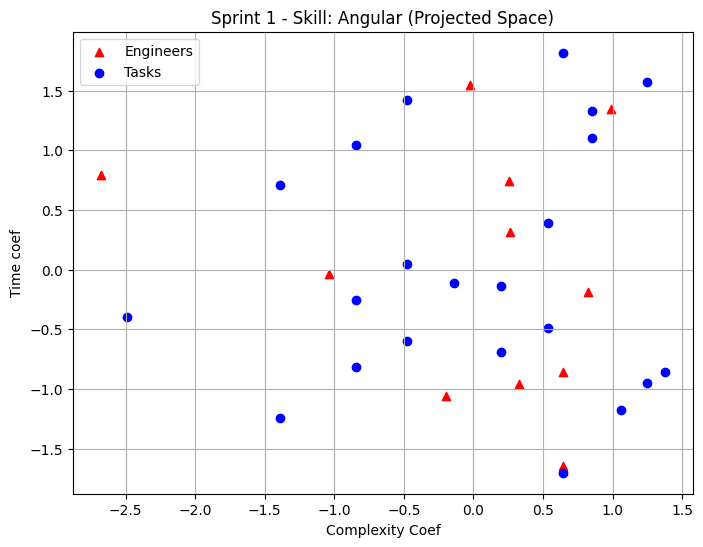

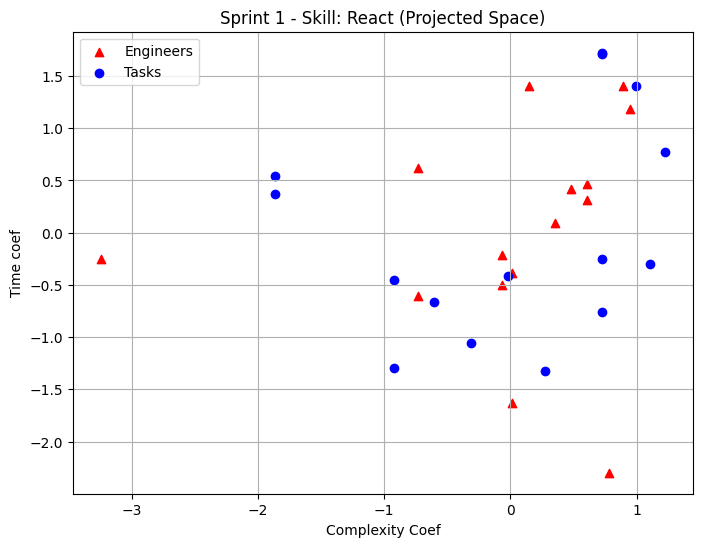

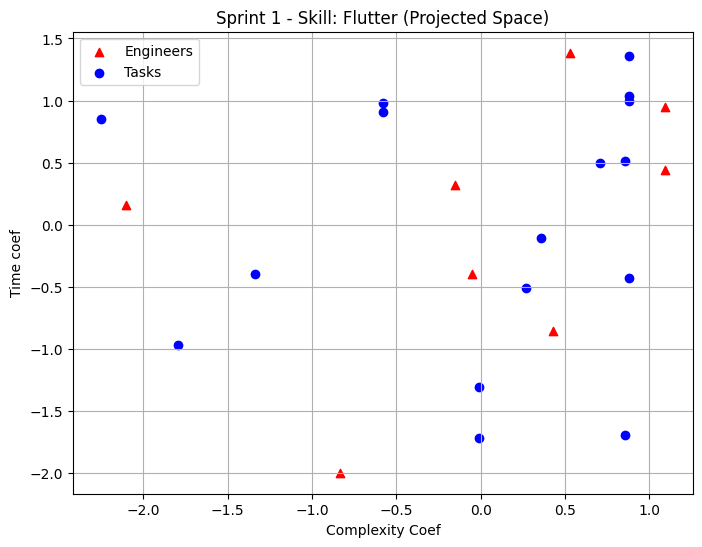

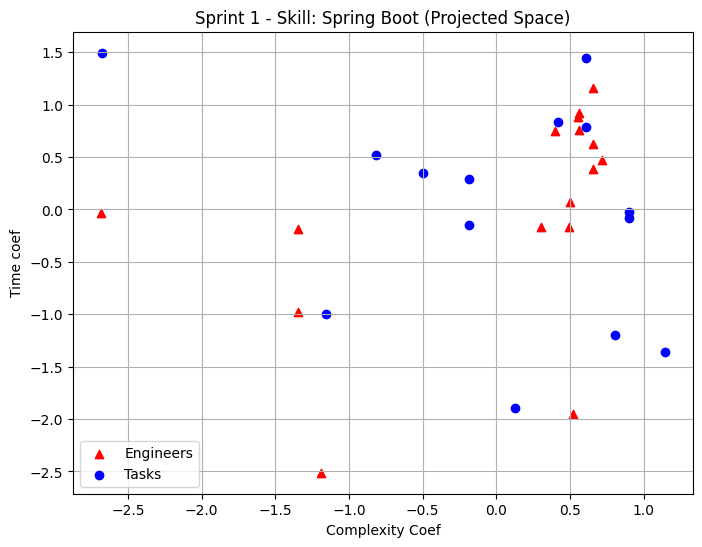

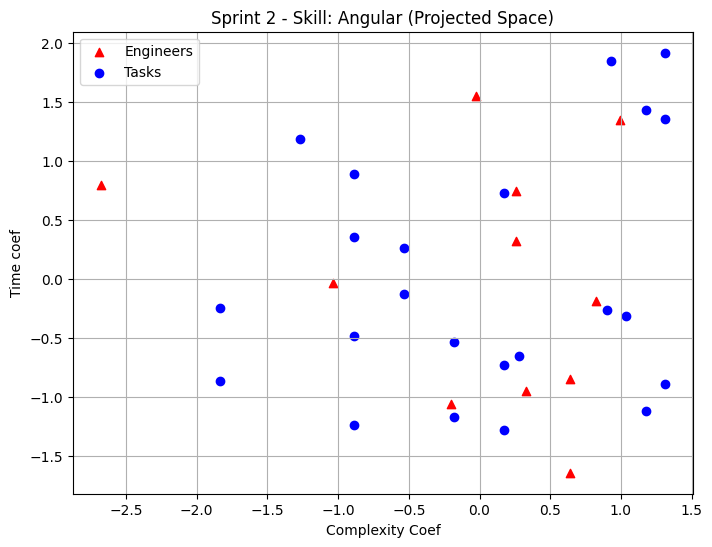

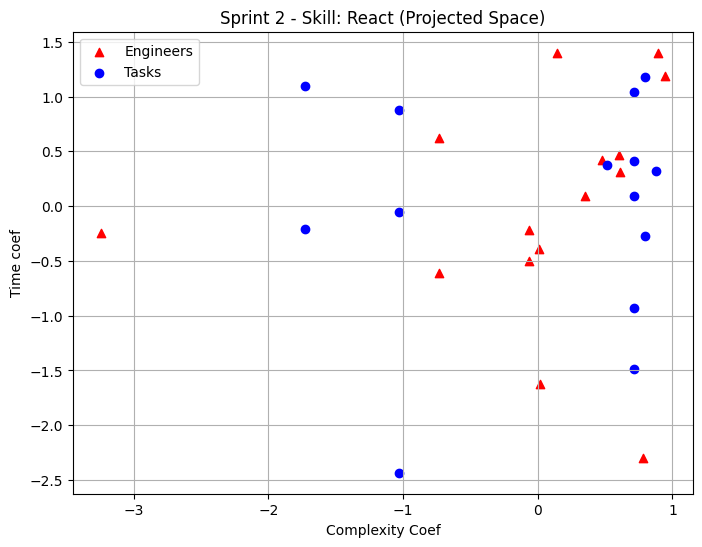

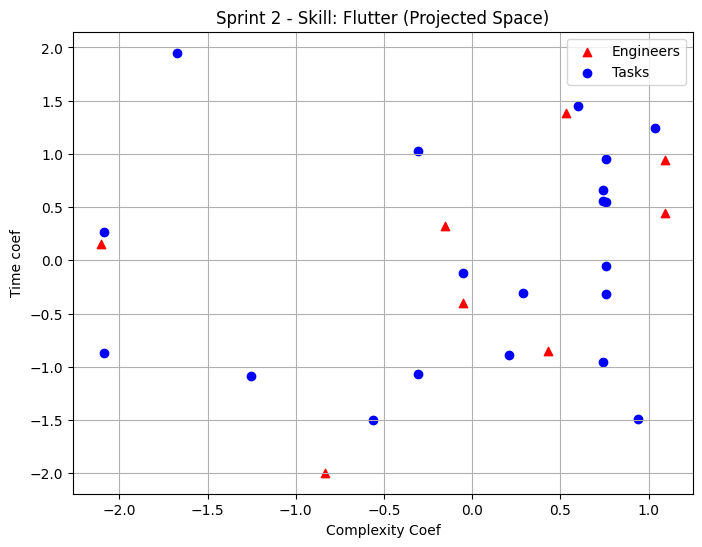

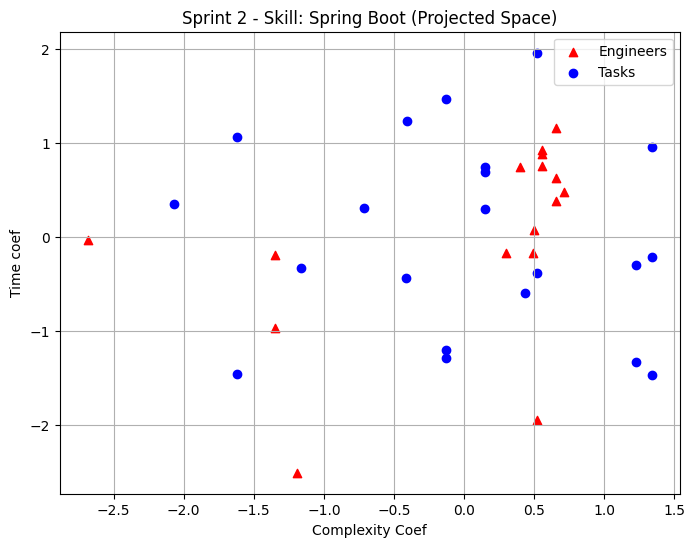

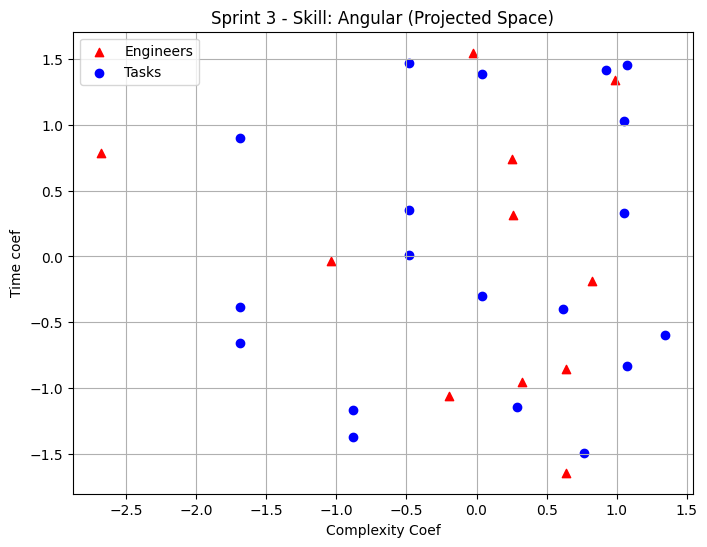

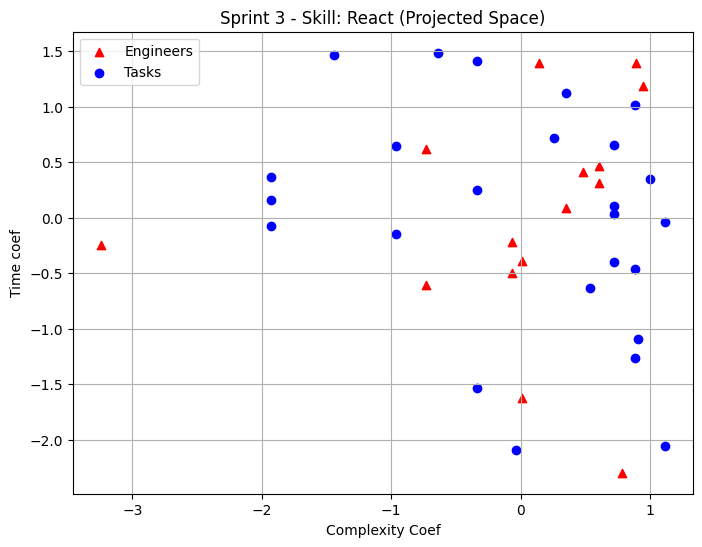

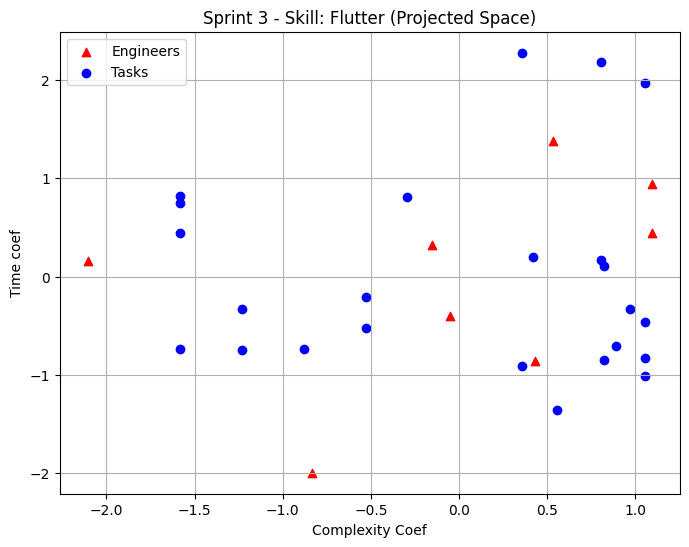

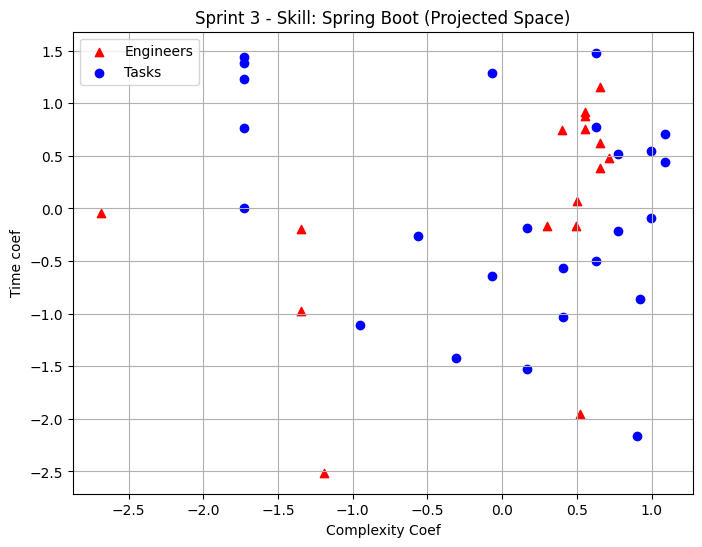

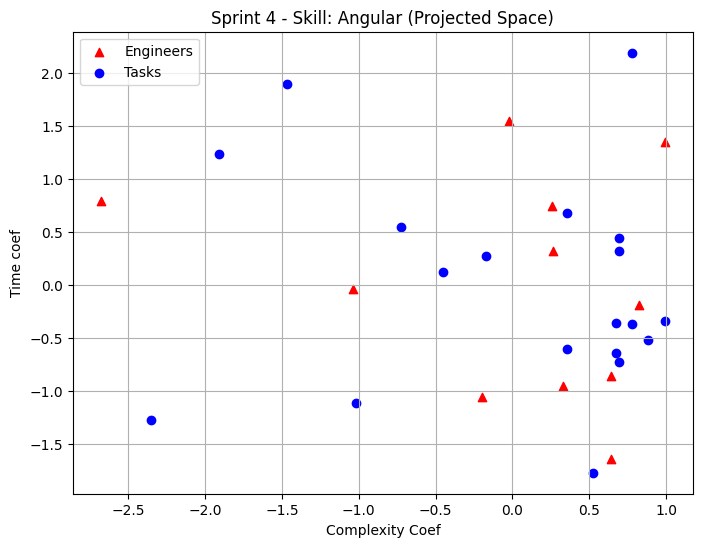

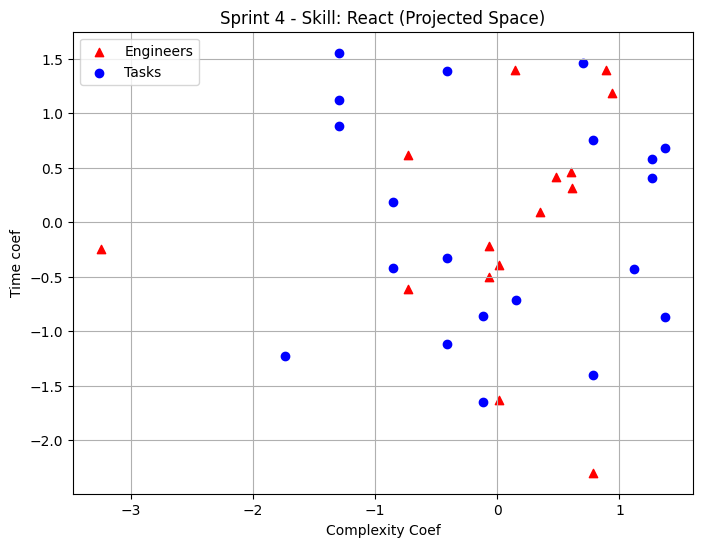

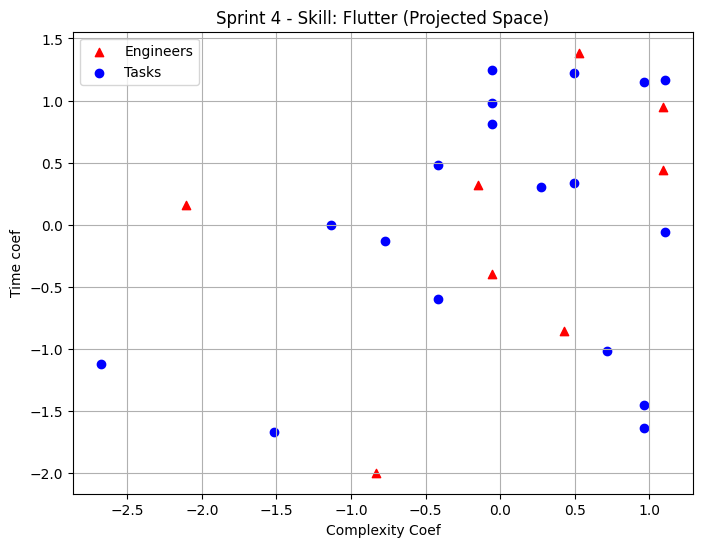

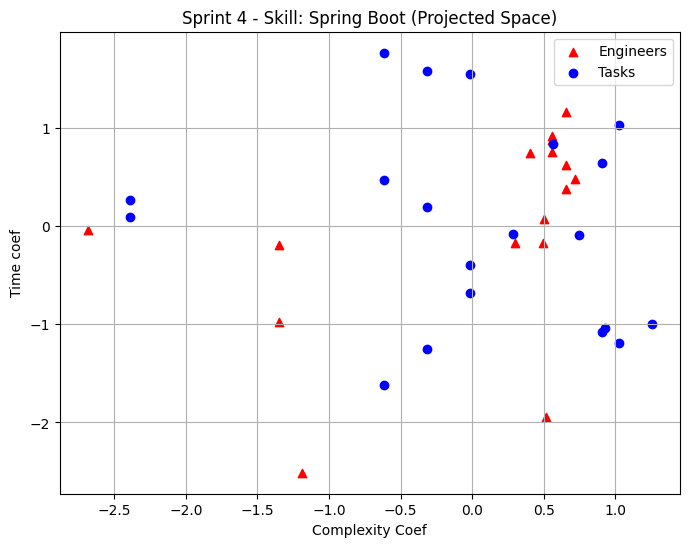

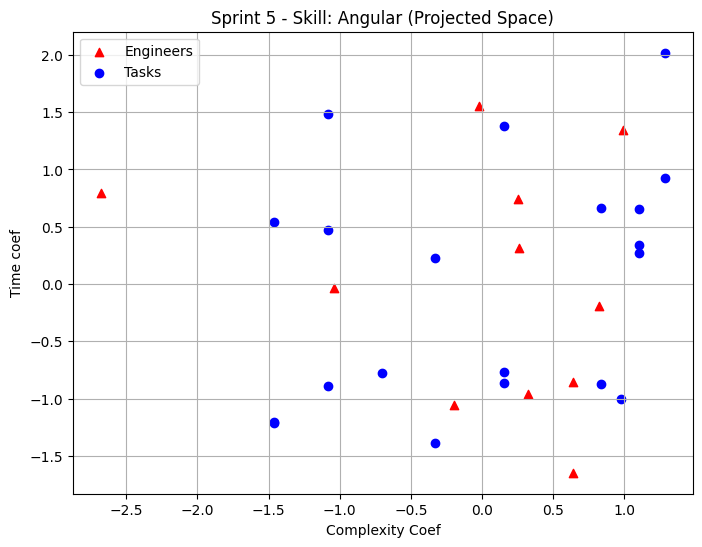

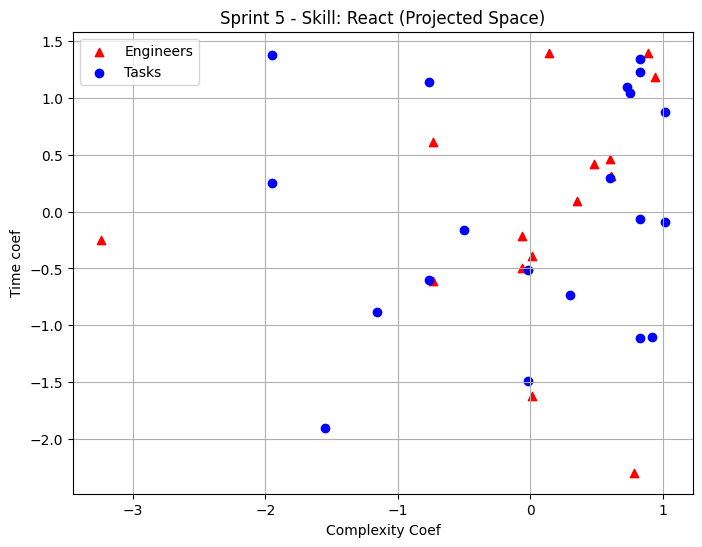

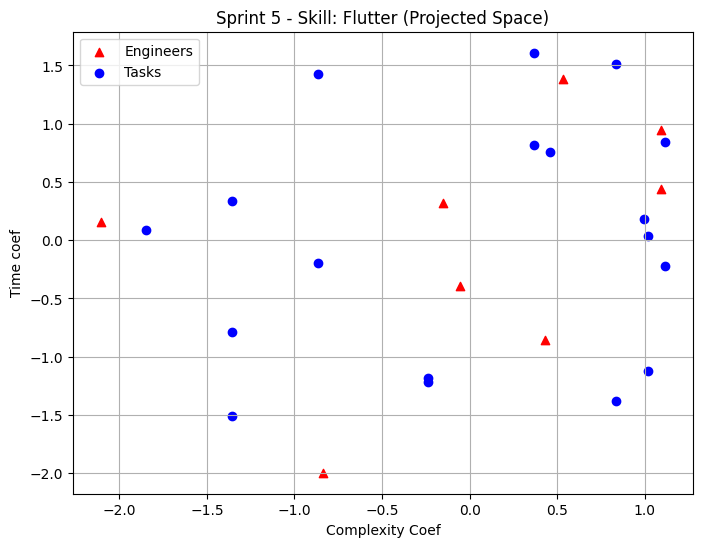

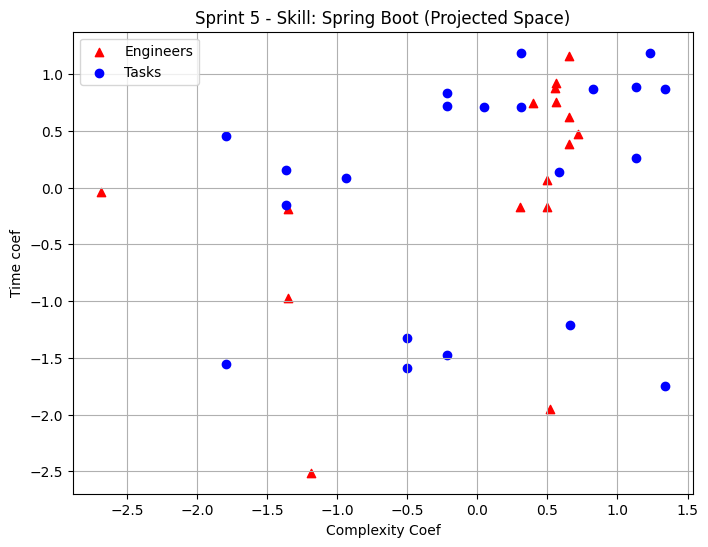

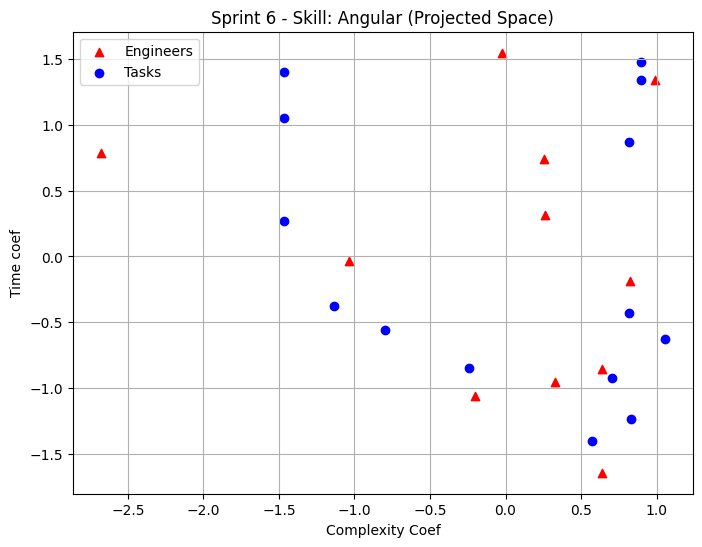

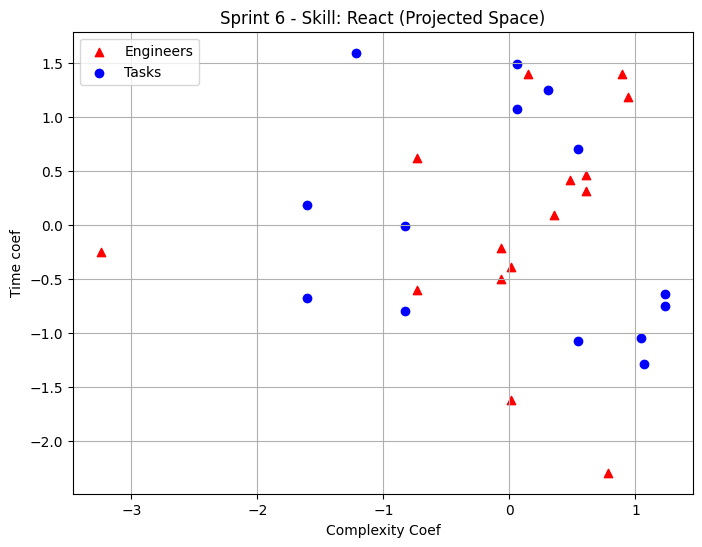

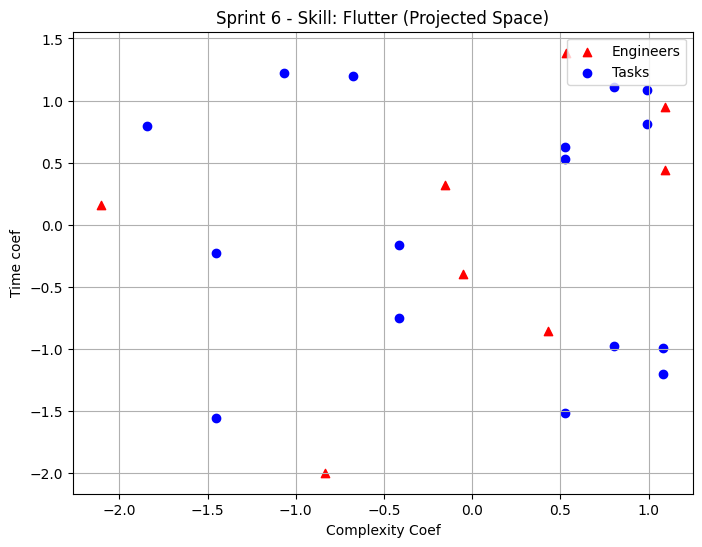

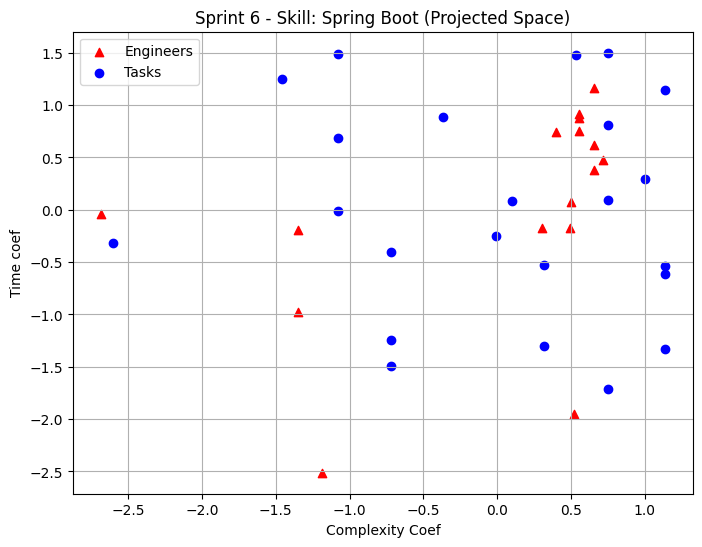

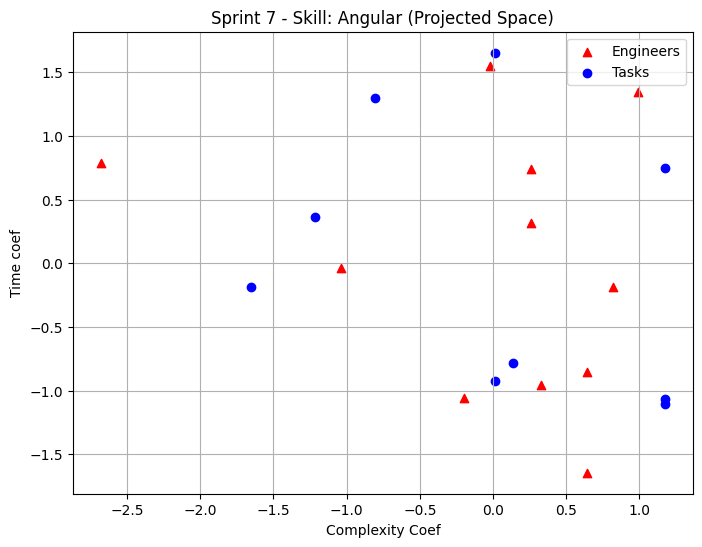

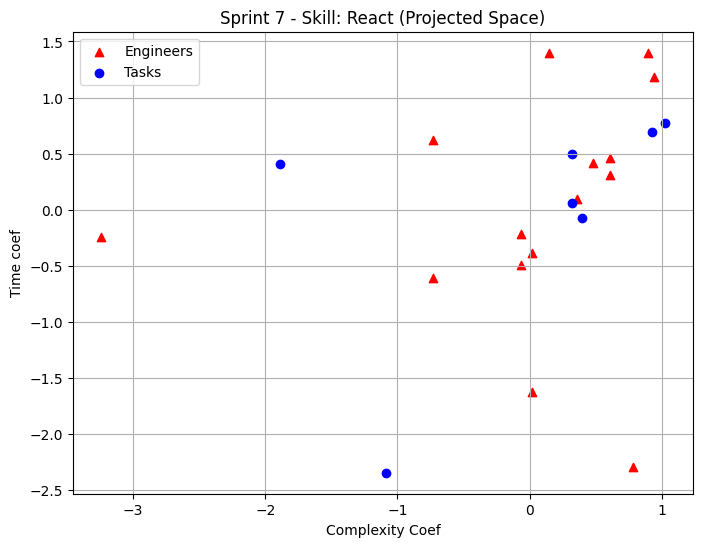

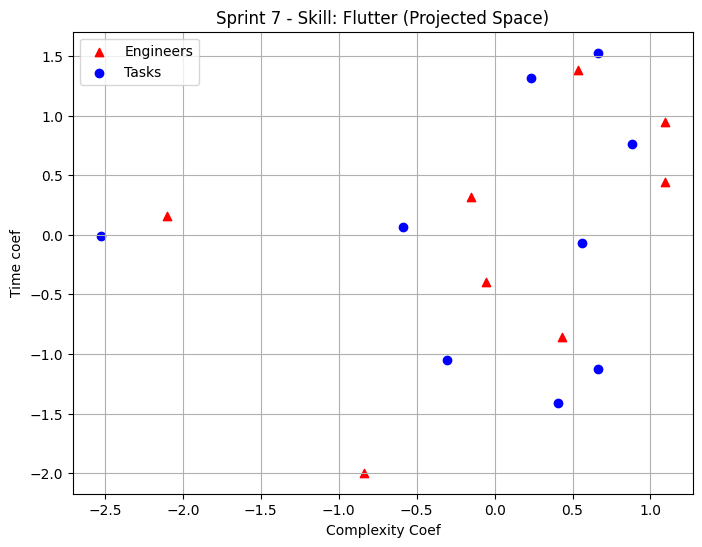

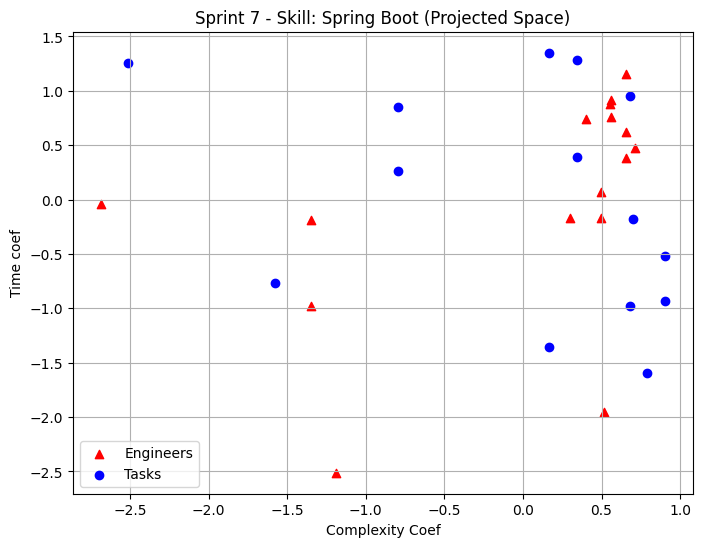

In [31]:
# Plot engineers and tasks for a specific sprint and skill
def plot_projected_engineers_and_tasks_by_skill(projected_data, sprint_number, skill):
    try:
        skill_data = projected_data[sprint_number][skill]
    except KeyError:
        print(f"Data for sprint '{sprint_number}', skill '{skill}' not found.")
        return

    engineers = skill_data.get("engineers", [])
    tasks = skill_data.get("tasks", [])

    # Extract projected coordinates
    eng_x = [e["engineer_vector"][0] for e in engineers]
    eng_y = [e["engineer_vector"][1] for e in engineers]

    task_x = [t["task_vector"][0] for t in tasks]
    task_y = [t["task_vector"][1] for t in tasks]

    plt.figure(figsize=(8, 6))
    plt.scatter(eng_x, eng_y, color='red', marker='^', label='Engineers')
    plt.scatter(task_x, task_y, color='blue', label='Tasks')

    plt.xlabel("Complexity Coef")
    plt.ylabel("Time coef")
    plt.title(f"Sprint {sprint_number} - Skill: {skill} (Projected Space)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Wrapper to plot all sprints and skills
def plot_all_projected_sprints(projected_sprint_list):
    for sprint_number, sprint_data in projected_sprint_list.items():
        for skill in sprint_data.keys():
            plot_projected_engineers_and_tasks_by_skill(projected_sprint_list, sprint_number, skill)


plot_all_projected_sprints(projected_sprint_list)


In [32]:
# Take tasks from tasks list and assign to it's engineers by sprint and skill
def assign_tasks_to_engineers(projected_sprint_list, task_limit=5, distance_threshold=None):
    modified_data = copy.deepcopy(projected_sprint_list)

    for sprint, sprint_data in modified_data.items():
        for skill, skill_data in sprint_data.items():
            tasks = skill_data["tasks"]
            engineers = skill_data["engineers"]

            for eng in engineers:
                eng["assigned_tasks"] = []

            unassigned_tasks = {t["task_id"]: t for t in tasks}

            task_vectors = {t["task_id"]: np.array(t["task_vector"]) for t in tasks}

            for eng in engineers:
                eng_vec = np.array(eng["engineer_vector"])
                distances = []

                for task_id, task in unassigned_tasks.items():
                    dist = euclidean(eng_vec, task_vectors[task_id])
                    if distance_threshold is None or dist <= distance_threshold:
                        distances.append((dist, task_id))

                distances.sort()

                assigned_now = []
                for dist, task_id in distances[:task_limit]:
                    task_with_dist = {**unassigned_tasks[task_id], "distance": dist}
                    assigned_now.append(task_with_dist)

                eng["assigned_tasks"].extend(assigned_now)

                for task in assigned_now:
                    unassigned_tasks.pop(task["task_id"], None)

            skill_data["tasks"] = list(unassigned_tasks.values())

    return modified_data

assigned_projected_sprint_list = assign_tasks_to_engineers(projected_sprint_list, 5, 1.5)

In [ ]:
# Evaluation metrics for baseline comparison
def evaluate_assignments(assigned_projected_sprint_list, tasks_list):
    total_tasks = len(tasks_list)
    assigned_tasks = 0
    distances = []
    load_counts = []

    for sprint, sprint_data in assigned_projected_sprint_list.items():
        for skill, skill_data in sprint_data.items():
            engineers = skill_data["engineers"]

            for eng in engineers:
                load_counts.append(len(eng["assigned_tasks"]))
                for task in eng["assigned_tasks"]:
                    assigned_tasks += 1
                    if "distance" in task:
                        distances.append(task["distance"])

    match_rate = assigned_tasks / total_tasks if total_tasks > 0 else 0
    avg_dist = np.mean(distances) if distances else 0
    unassigned_pct = (1 - match_rate) * 100
    load_var = np.var(load_counts) if load_counts else 0

    return {
        "match_rate": match_rate,
        "avg_dist": avg_dist,
        "unassigned_pct": unassigned_pct,
        "load_var": load_var
    }

output_metrics = evaluate_assignments(assigned_projected_sprint_list, tasks_mock)
print("Output Metrics:", output_metrics)


Output Metrics: {'match_rate': 0.982, 'avg_dist': np.float64(0.8523003777573998), 'unassigned_pct': 1.8000000000000016, 'load_var': np.float64(3.629134693877551)}


In [34]:
with open('assigned_projected_sprint_list.json', 'w') as f:
    json.dump(assigned_projected_sprint_list, f, indent=4)

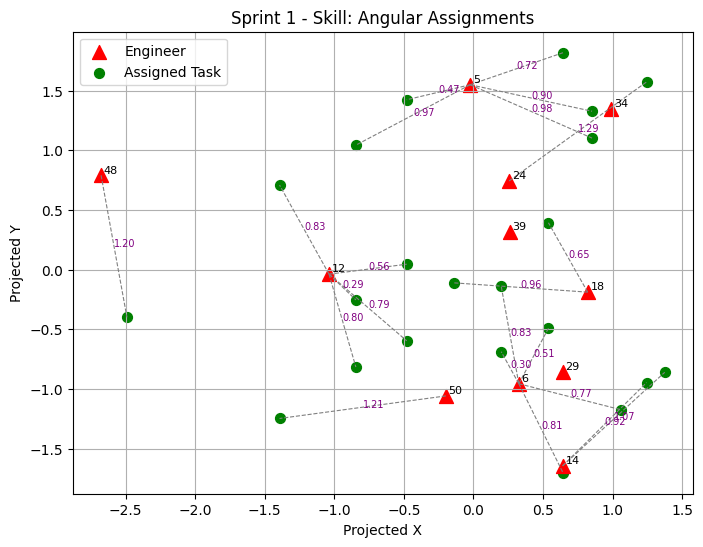

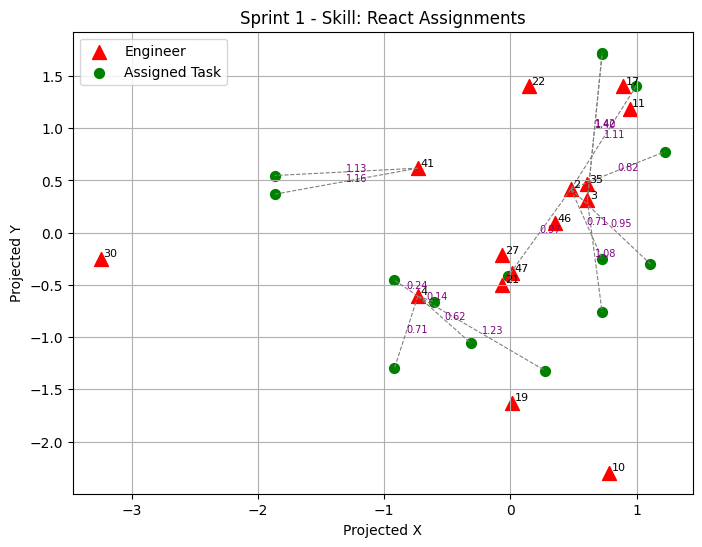

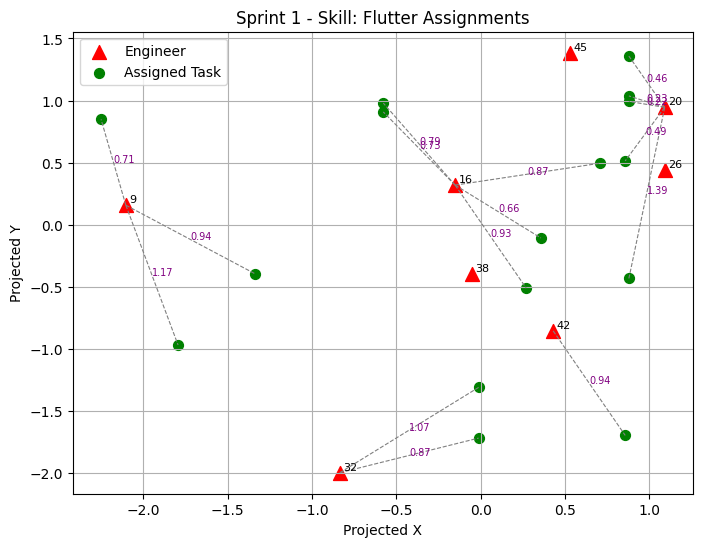

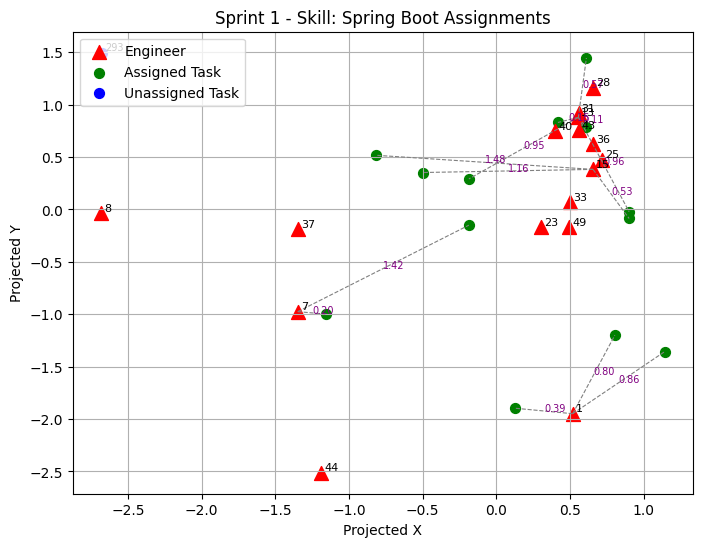

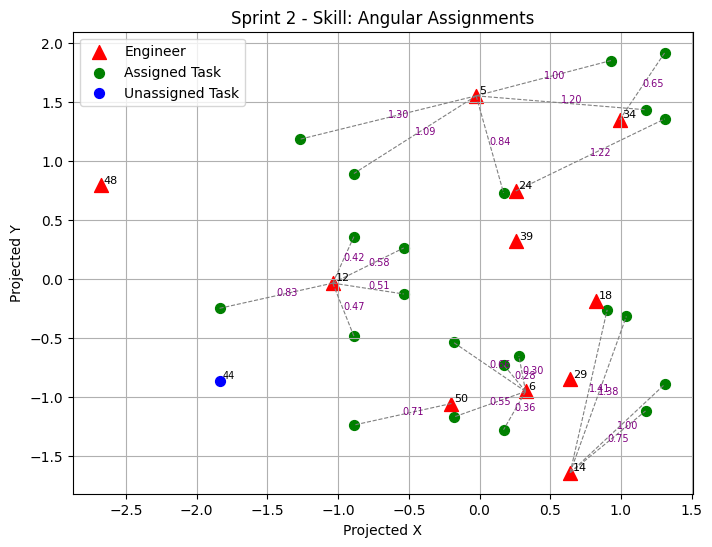

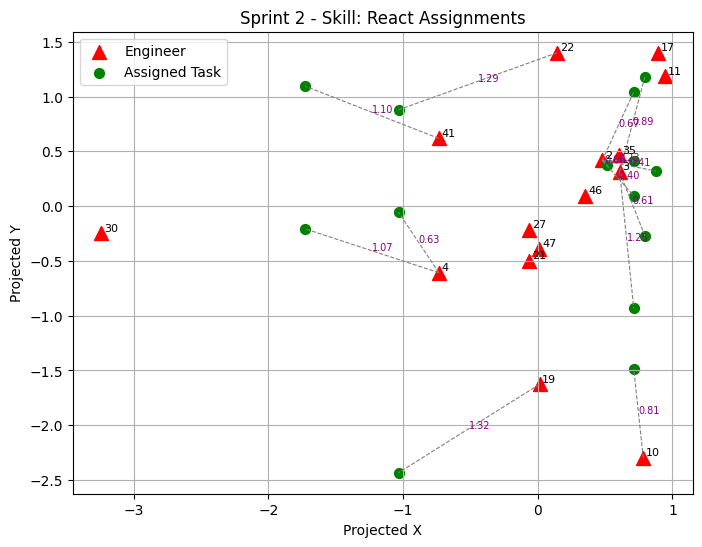

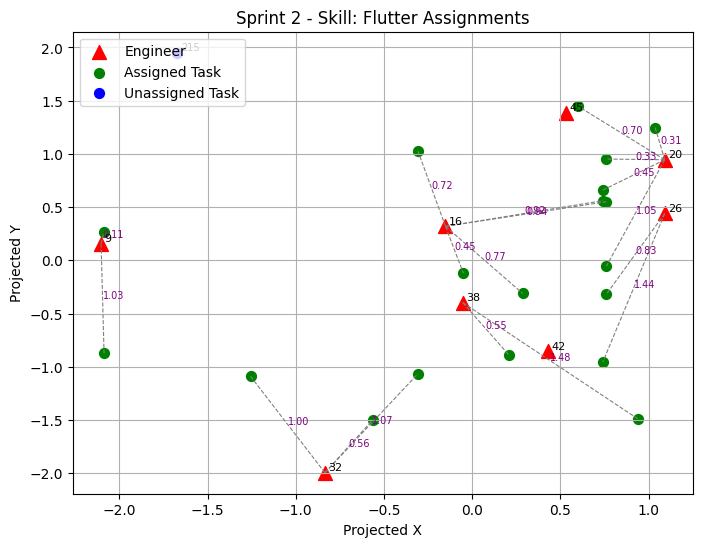

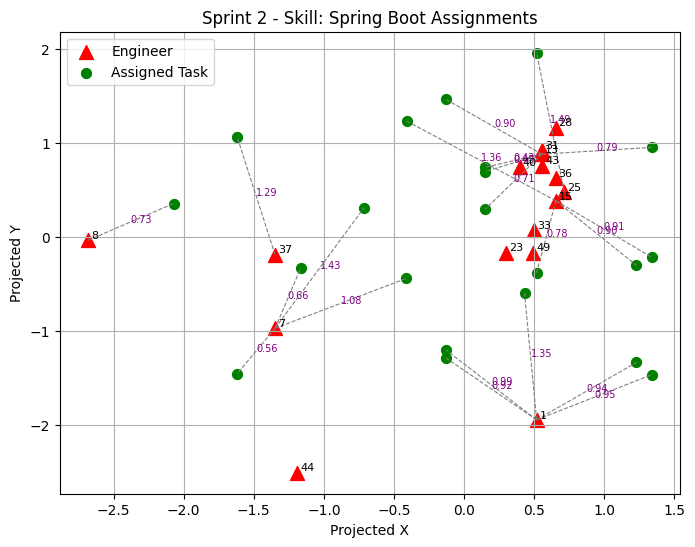

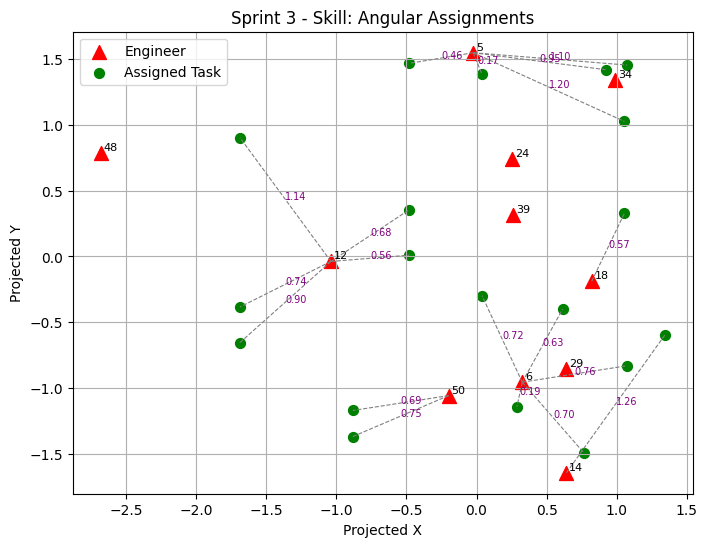

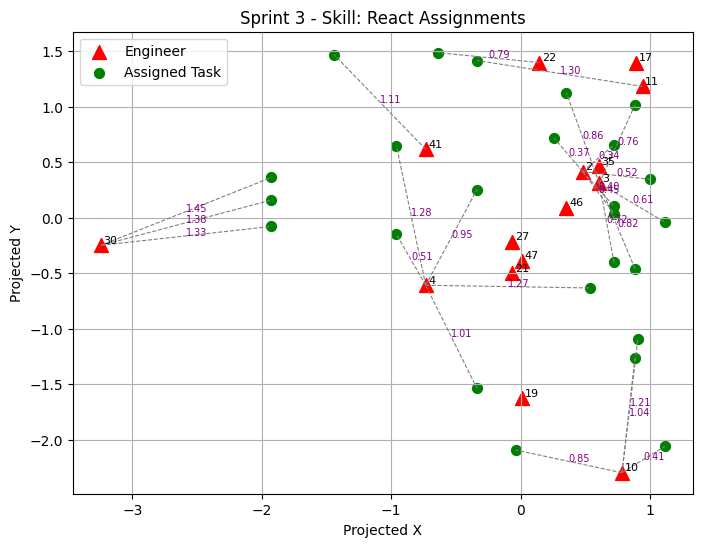

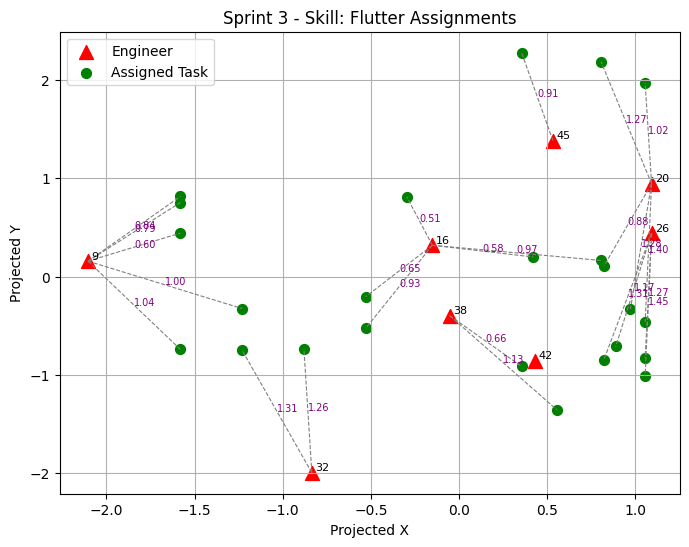

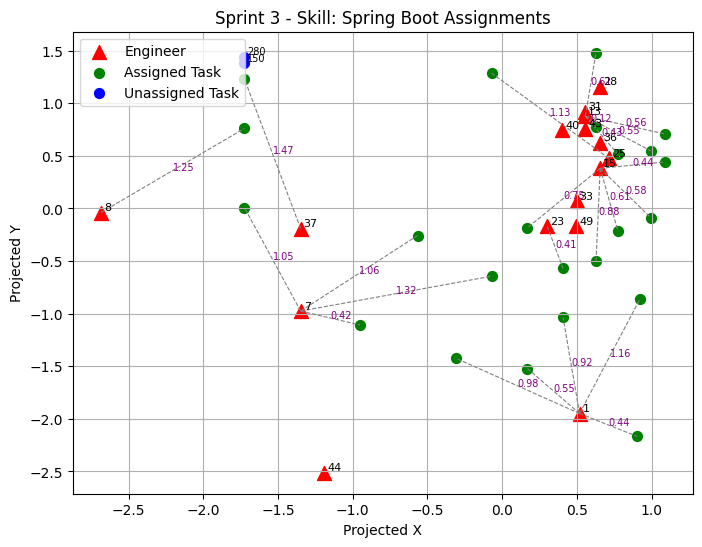

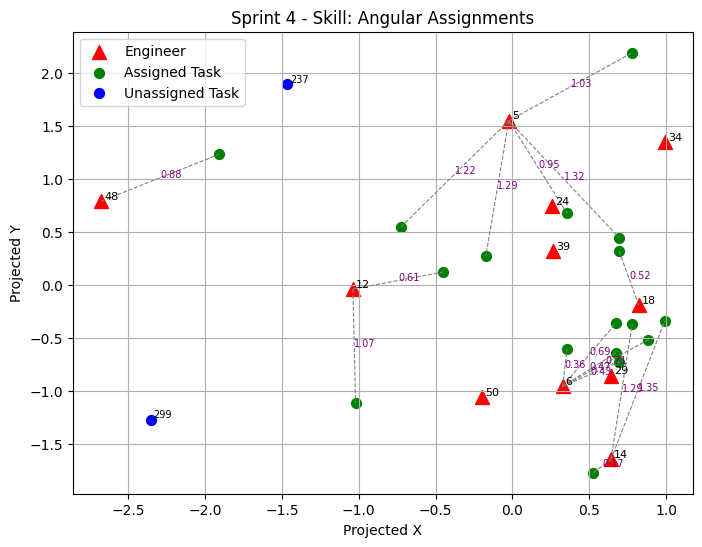

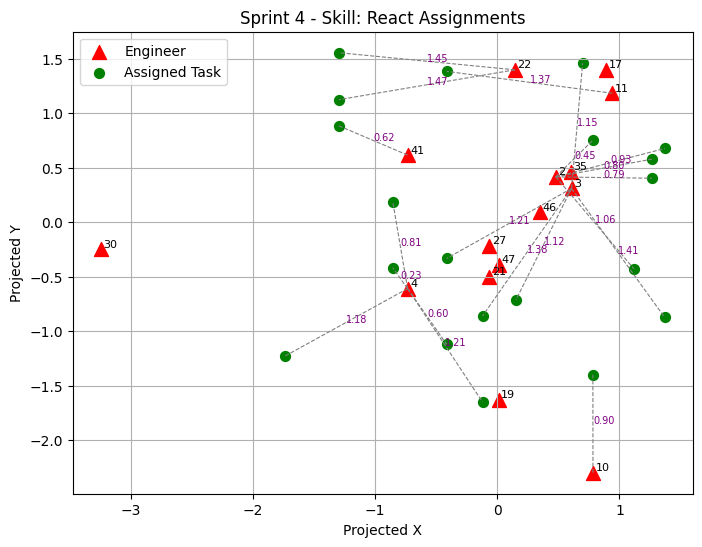

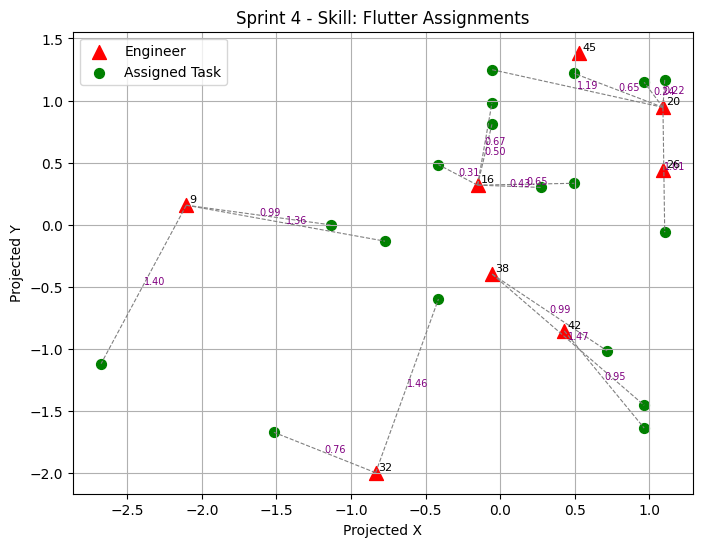

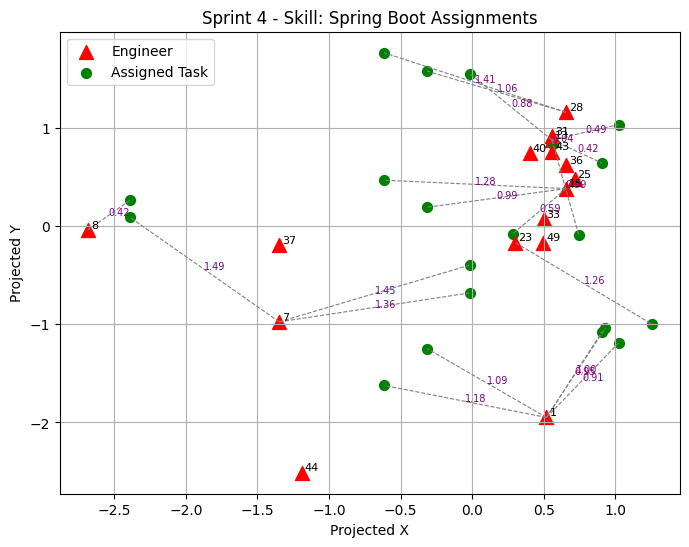

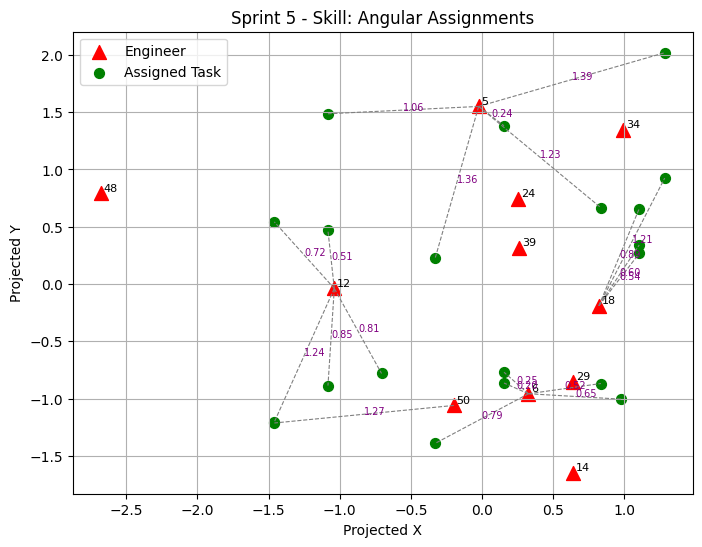

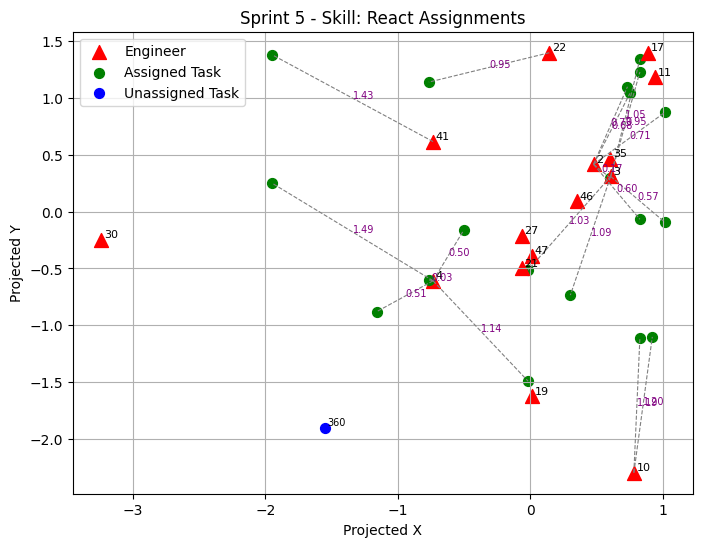

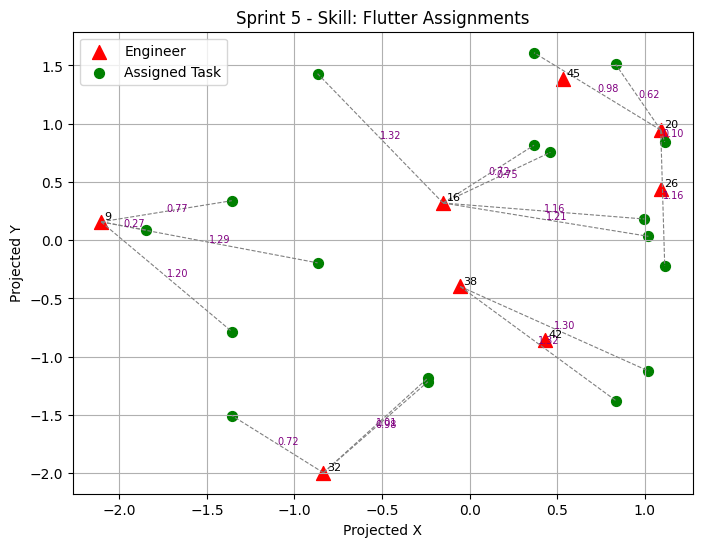

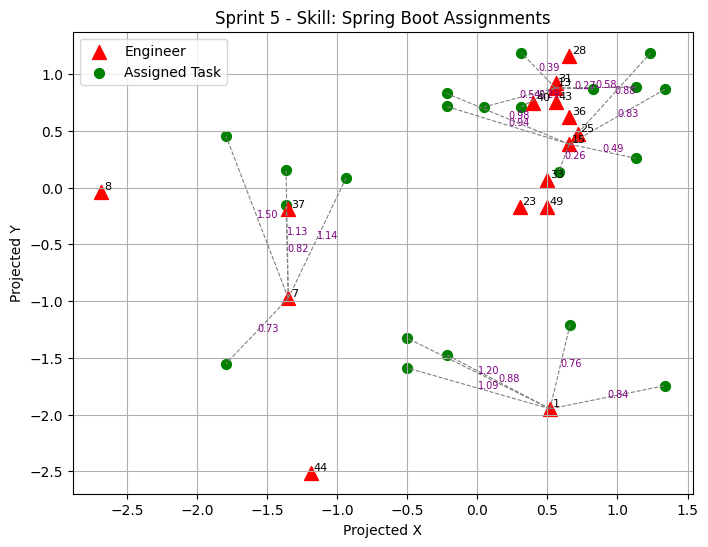

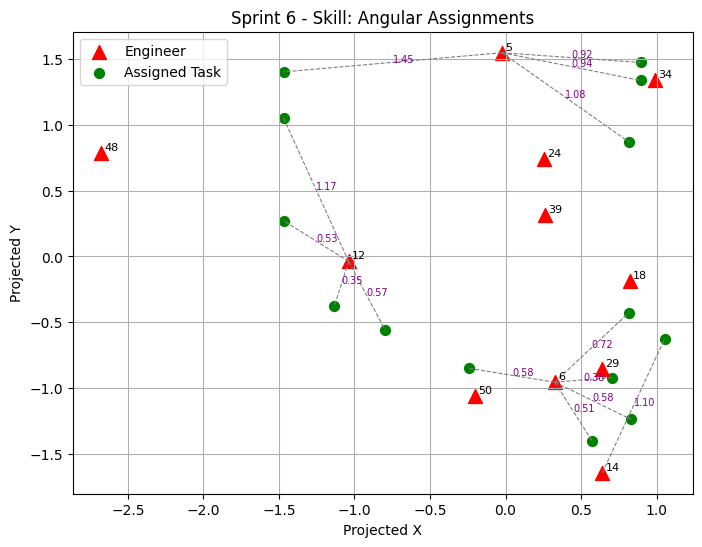

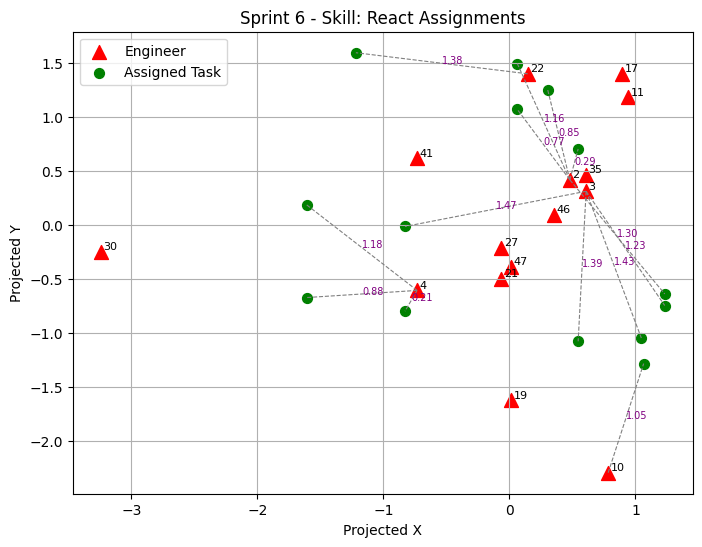

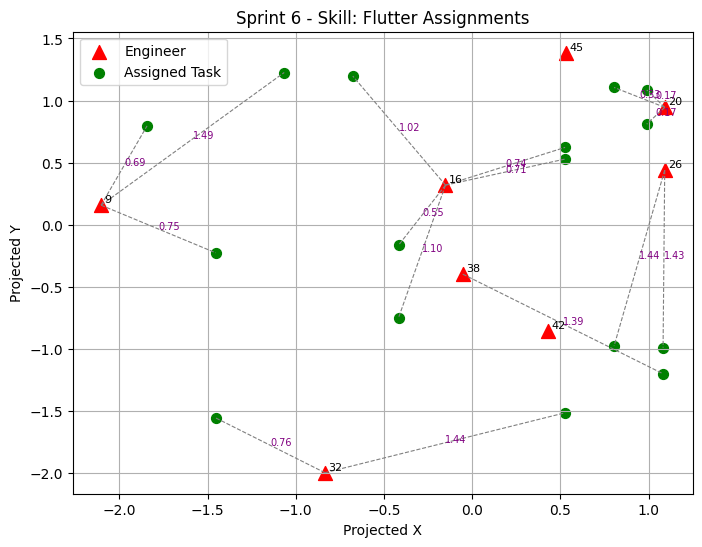

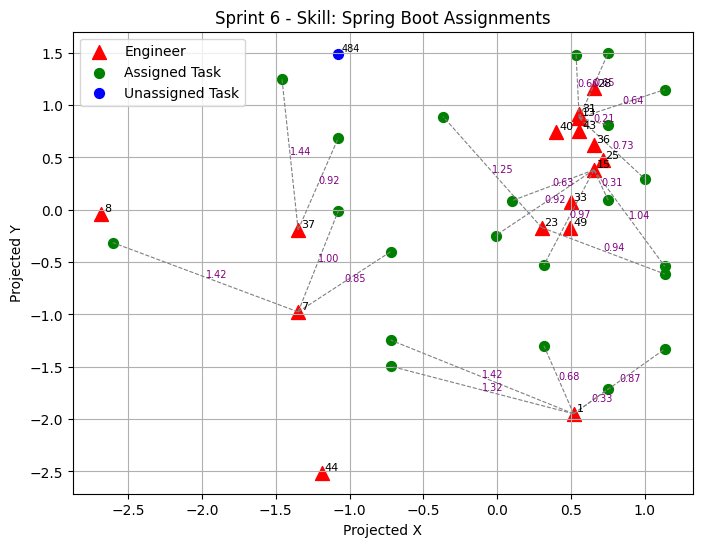

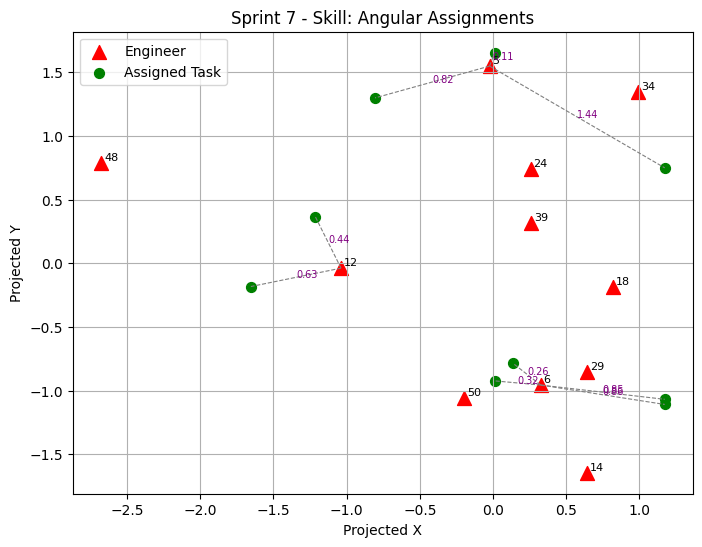

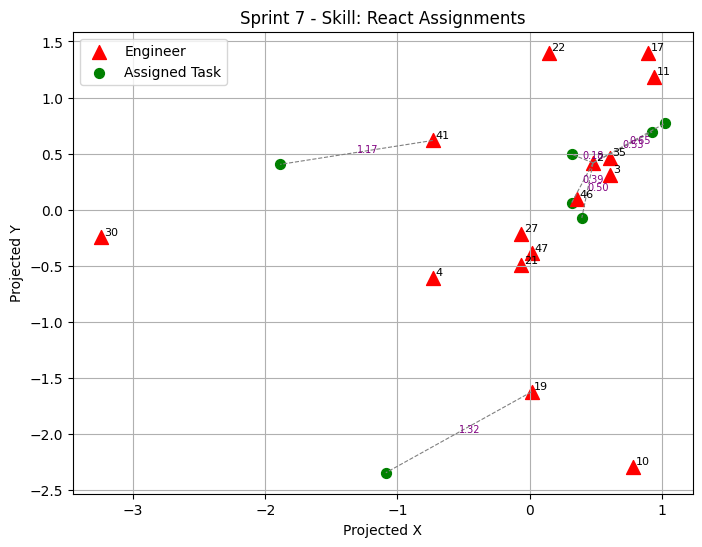

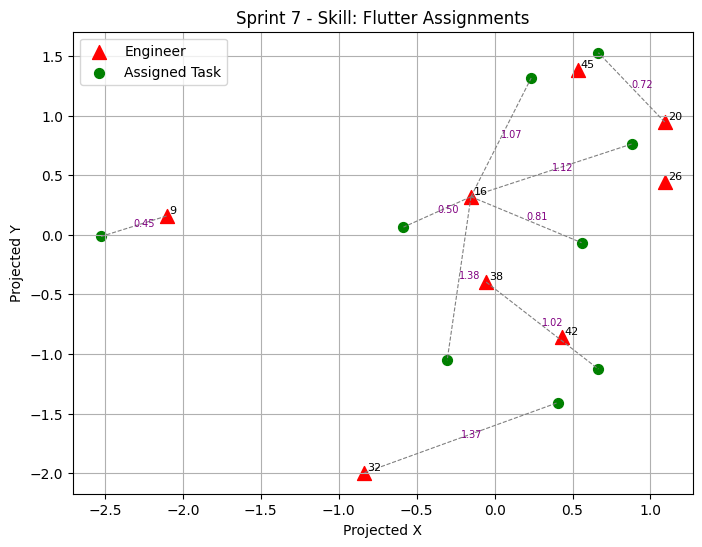

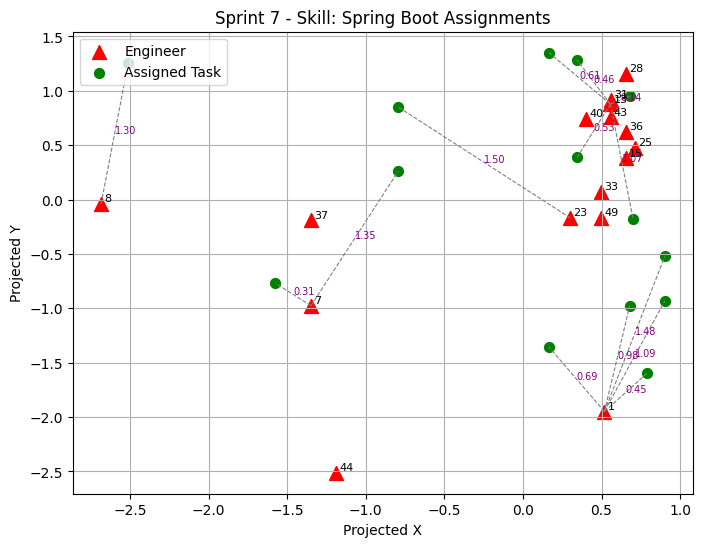

In [35]:
# Plot assigned tasks and engineers
def plot_all_assignments(modified_data):
    for sprint_number, sprint_data in modified_data.items():
        for skill, skill_data in sprint_data.items():
            engineers = skill_data["engineers"]
            unassigned_tasks = skill_data["tasks"]  # Leftovers only

            plt.figure(figsize=(8, 6))

            # Plot engineers
            for eng in engineers:
                ex, ey = eng["engineer_vector"]
                plt.scatter(ex, ey, c="red", marker="^", s=100,
                            label="Engineer" if "Engineer" not in plt.gca().get_legend_handles_labels()[1] else "")
                plt.text(ex + 0.02, ey + 0.02, eng["engineer_id"], fontsize=8)

                # Draw lines to assigned tasks with distance labels
                for task in eng["assigned_tasks"]:
                    tx, ty = task["task_vector"]
                    dist = task.get("distance", None)

                    plt.scatter(tx, ty, c="green", s=50,
                                label="Assigned Task" if "Assigned Task" not in plt.gca().get_legend_handles_labels()[1] else "")
                    plt.plot([ex, tx], [ey, ty], c="gray", linestyle="--", linewidth=0.8)

                    if dist is not None:
                        mid_x = (ex + tx) / 2
                        mid_y = (ey + ty) / 2
                        plt.text(mid_x, mid_y, f"{dist:.2f}", fontsize=7, color="purple")

            # Plot leftover tasks (unassigned) in blue
            for task in unassigned_tasks:
                tx, ty = task["task_vector"]
                plt.scatter(tx, ty, c="blue", s=50,
                            label="Unassigned Task" if "Unassigned Task" not in plt.gca().get_legend_handles_labels()[1] else "")
                plt.text(tx + 0.02, ty + 0.02, task["task_id"], fontsize=7)

            # Add title, labels, legend
            plt.title(f"Sprint {sprint_number} - Skill: {skill} Assignments")
            plt.xlabel("Projected X")
            plt.ylabel("Projected Y")
            plt.grid(True)
            plt.legend(loc="upper left")
            plt.show()


plot_all_assignments(assigned_projected_sprint_list)